# Task 7: LoRA Fine-Tuning

## Objective

Implement a simplified Low-Rank Adaptation (LoRA) approach for fine-tuning a neural network.

This task demonstrates:

- LoRA concept
- Frozen base model
- Trainable LoRA parameters
- Forward propagation
- Loss calculation
- Backpropagation
- Parameter updates
- Comparison of trainable parameters

LoRA reduces the number of parameters that need to be trained by keeping the original model frozen and training small additional matrices.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0+cpu


## Step 1: Create a Base Model

We create a small neural network that represents a pretrained model.

Normally, a large language model would contain millions or billions of parameters.
For demonstration, we use a small model.

In [2]:
class BaseModel(nn.Module):

    def __init__(self, input_size=10, hidden_size=32, output_size=5):

        super().__init__()

        self.layer1 = nn.Linear(
            input_size,
            hidden_size
        )

        self.layer2 = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        x = F.relu(
            self.layer1(x)
        )

        x = self.layer2(x)

        return x


base_model = BaseModel()

print(base_model)

BaseModel(
  (layer1): Linear(in_features=10, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=5, bias=True)
)


## Step 2: Count Base Model Parameters

We calculate the total number of parameters in the original model.

In [3]:
total_parameters = sum(
    parameter.numel()
    for parameter in base_model.parameters()
)

print(
    "Total base model parameters:",
    total_parameters
)

Total base model parameters: 517


## Step 3: Freeze the Base Model

In LoRA, the original model parameters are frozen.

They are not updated during fine-tuning.

Only the newly added LoRA parameters are trained.

In [4]:
for parameter in base_model.parameters():

    parameter.requires_grad = False

print("Base model parameters are frozen.")

Base model parameters are frozen.


## Step 4: Create a LoRA Layer

LoRA adds two small trainable matrices:

A and B.

Instead of directly updating the original weight matrix, LoRA learns a low-rank update:

ΔW = B × A

The original weights remain frozen.

In [5]:
class LoRALayer(nn.Module):

    def __init__(
        self,
        input_size,
        output_size,
        rank=2
    ):

        super().__init__()

        self.A = nn.Parameter(
            torch.randn(
                rank,
                input_size
            ) * 0.01
        )

        self.B = nn.Parameter(
            torch.zeros(
                output_size,
                rank
            )
        )

        self.scale = 1.0 / rank

    def forward(self, x):

        lora_update = (
            x @ self.A.T
        ) @ self.B.T

        return lora_update * self.scale

## Step 5: Build the LoRA Model

The base model remains frozen.

The LoRA layer learns a small update that is added to the base model output.

In [6]:
class LoRAModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.base_model = BaseModel()

        for parameter in self.base_model.parameters():

            parameter.requires_grad = False

        self.lora = LoRALayer(
            input_size=10,
            output_size=5,
            rank=2
        )

    def forward(self, x):

        base_output = self.base_model(x)

        lora_output = self.lora(x)

        return base_output + lora_output


model = LoRAModel()

print(model)

LoRAModel(
  (base_model): BaseModel(
    (layer1): Linear(in_features=10, out_features=32, bias=True)
    (layer2): Linear(in_features=32, out_features=5, bias=True)
  )
  (lora): LoRALayer()
)


## Step 6: Count Trainable Parameters

LoRA should train only a small number of additional parameters.

We compare the total parameters with the trainable parameters.

In [7]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Total parameters:",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

Total parameters: 547
Trainable parameters: 30


## Step 7: Trainable Parameter Percentage

This shows how much smaller the trainable portion is compared with the complete model.

In [8]:
trainable_percentage = (
    trainable_parameters
    / total_parameters
) * 100

print(
    "Trainable parameters:",
    round(
        trainable_percentage,
        2
    ),
    "%"
)

Trainable parameters: 5.48 %


## Step 8: Create Training Data

We create a small synthetic dataset.

The model will learn to map input vectors to target outputs.

In [9]:
X = torch.randn(
    100,
    10
)

y = torch.randint(
    0,
    5,
    (100,)
)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: torch.Size([100, 10])
Target shape: torch.Size([100])


## Step 9: Create Optimizer

The optimizer receives only the trainable LoRA parameters.

The frozen base model will not be updated.

In [10]:
trainable_parameters_list = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.Adam(
    trainable_parameters_list,
    lr=0.01
)

print("Optimizer created.")

Optimizer created.


## Step 10: Fine-Tune Using LoRA

During training:

1. Forward pass
2. Calculate loss
3. Backpropagation
4. Update LoRA parameters

The base model remains frozen.

In [11]:
loss_history = []

epochs = 50

for epoch in range(epochs):

    optimizer.zero_grad()

    output = model(X)

    loss = F.cross_entropy(
        output,
        y
    )

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 10: Loss = 1.6234
Epoch 20: Loss = 1.6031
Epoch 30: Loss = 1.5721
Epoch 40: Loss = 1.5417
Epoch 50: Loss = 1.5182


## Step 11: Training Loss

The loss shows whether the LoRA parameters are learning during fine-tuning.

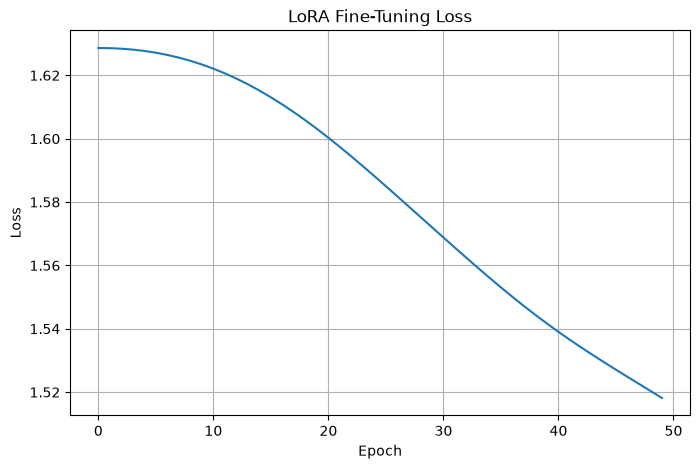

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "LoRA Fine-Tuning Loss"
)

plt.grid(True)

plt.show()

## Step 12: Verify Frozen Base Model

We verify that the base model parameters remain frozen while the LoRA parameters are trainable.

In [13]:
print("Base Model Parameters:")

for name, parameter in model.base_model.named_parameters():

    print(
        name,
        "Trainable:",
        parameter.requires_grad
    )

print("\nLoRA Parameters:")

for name, parameter in model.lora.named_parameters():

    print(
        name,
        "Trainable:",
        parameter.requires_grad
    )

Base Model Parameters:
layer1.weight Trainable: False
layer1.bias Trainable: False
layer2.weight Trainable: False
layer2.bias Trainable: False

LoRA Parameters:
A Trainable: True
B Trainable: True


## Step 13: Make Predictions

After fine-tuning, we use the model to predict classes for the training examples.

In [14]:
with torch.no_grad():

    predictions = torch.argmax(
        model(X),
        dim=1
    )

print("First 20 predictions:")
print(predictions[:20])

print("\nFirst 20 actual labels:")
print(y[:20])

First 20 predictions:
tensor([3, 1, 2, 0, 3, 1, 1, 0, 3, 0, 1, 0, 0, 1, 1, 0, 1, 3, 0, 0])

First 20 actual labels:
tensor([3, 2, 0, 2, 3, 1, 1, 2, 1, 0, 0, 3, 3, 4, 4, 1, 2, 2, 0, 2])


## Step 14: Calculate Accuracy

In [15]:
accuracy = (
    predictions == y
).float().mean()

print(
    "Training Accuracy:",
    round(
        accuracy.item() * 100,
        2
    ),
    "%"
)

Training Accuracy: 27.0 %


## Step 15: Results

The LoRA experiment demonstrates that:

- The original model can remain frozen.
- Only LoRA parameters are trained.
- The number of trainable parameters is much smaller.
- The model can still adapt to the training data.

In [16]:
print("========== TASK 7 RESULTS ==========")

print(
    "Total Parameters:",
    total_parameters
)

print(
    "Trainable Parameters:",
    trainable_parameters
)

print(
    "Trainable Percentage:",
    round(
        trainable_percentage,
        2
    ),
    "%"
)

print(
    "Final Loss:",
    round(
        loss_history[-1],
        4
    )
)

print(
    "Training Accuracy:",
    round(
        accuracy.item() * 100,
        2
    ),
    "%"
)

print("====================================")

========== TASK 7 RESULTS ==========
Total Parameters: 547
Trainable Parameters: 30
Trainable Percentage: 5.48 %
Final Loss: 1.5182
Training Accuracy: 27.0 %


# Conclusion

A simplified LoRA fine-tuning approach was implemented.

The base model parameters were frozen, while two small trainable matrices were introduced to learn a low-rank update.

This significantly reduces the number of parameters that need to be trained compared with updating the entire model.

LoRA is therefore useful for parameter-efficient fine-tuning of large models because it reduces training cost and memory requirements while allowing the model to adapt to a specific task.